In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [3]:
df=pd.read_csv('D:/python ml projects/credit card fraud detection/data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:

print("CLASS DISTRIBUTION:")


fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

print(f"\nTotal transactions: {len(df)}")
print(f"Legitimate transactions: {len(legit)}")
print(f"Fraud transactions: {len(fraud)}")
print(f"\nFraud percentage: {len(fraud)/len(df)*100:.4f}%")
print(f"Legitimate percentage: {len(legit)/len(df)*100:.4f}%")

CLASS DISTRIBUTION:

Total transactions: 284807
Legitimate transactions: 284315
Fraud transactions: 492

Fraud percentage: 0.1727%
Legitimate percentage: 99.8273%


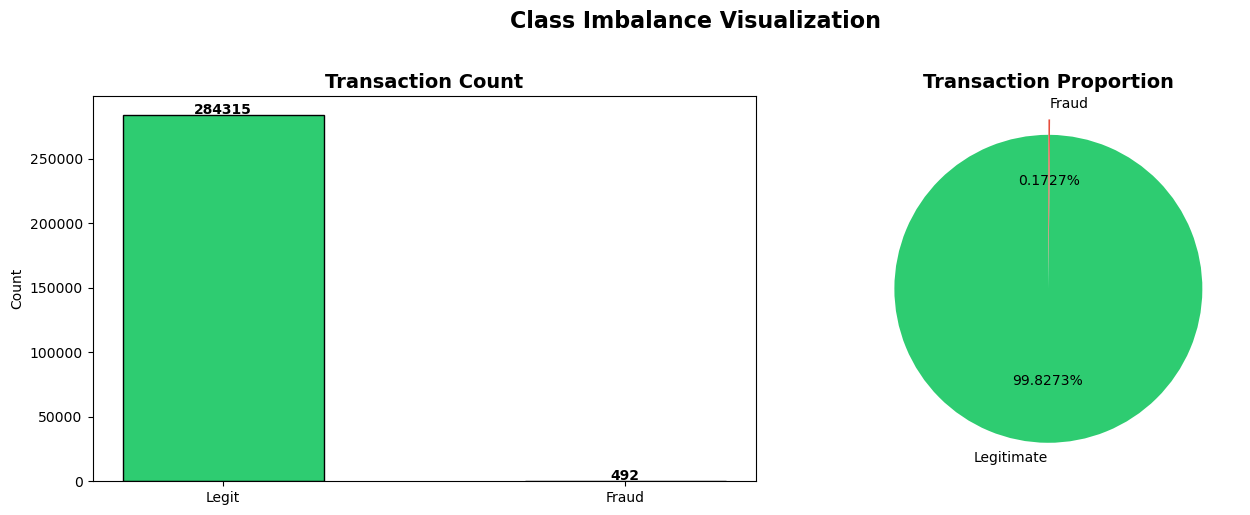

In [17]:
#Visualising fraud vs legitimate counts
fig,axes=plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(['Legit','Fraud'],
        [len(legit),len(fraud)],
color=['#2ecc71', '#e74c3c'],
            edgecolor='black',
            width=0.5)
axes[0].set_title('Transaction Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')

for i, v in enumerate([len(legit), len(fraud)]):
    axes[0].text(i, v + 500, str(v), ha='center', fontweight='bold')

# Plot 2: Pie chart
axes[1].pie([len(legit), len(fraud)],
            labels=['Legitimate', 'Fraud'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.4f%%',
            startangle=90,
            explode=(0, 0.1))
axes[1].set_title('Transaction Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Class Imbalance Visualization', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

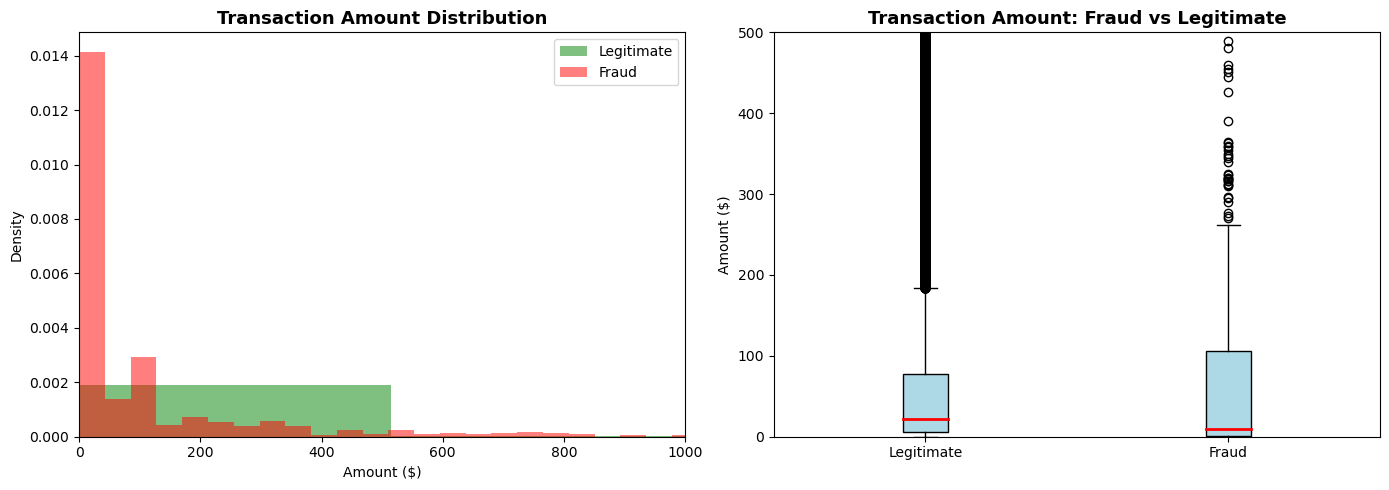

In [18]:
# Compare transaction amounts: fraud vs legitimate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of amounts
axes[0].hist(legit['Amount'], bins=50, alpha=0.5, 
             color='green', label='Legitimate', density=True)
axes[0].hist(fraud['Amount'], bins=50, alpha=0.5, 
             color='red', label='Fraud', density=True)
axes[0].set_title('Transaction Amount Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].set_xlim(0, 1000)  # Zoom in to see pattern better

# Plot 2: Boxplot comparison
axes[1].boxplot([legit['Amount'], fraud['Amount']], 
                labels=['Legitimate', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Transaction Amount: Fraud vs Legitimate', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Amount ($)')
axes[1].set_ylim(0, 500)  # Zoom to see boxes better

plt.tight_layout()
plt.show()


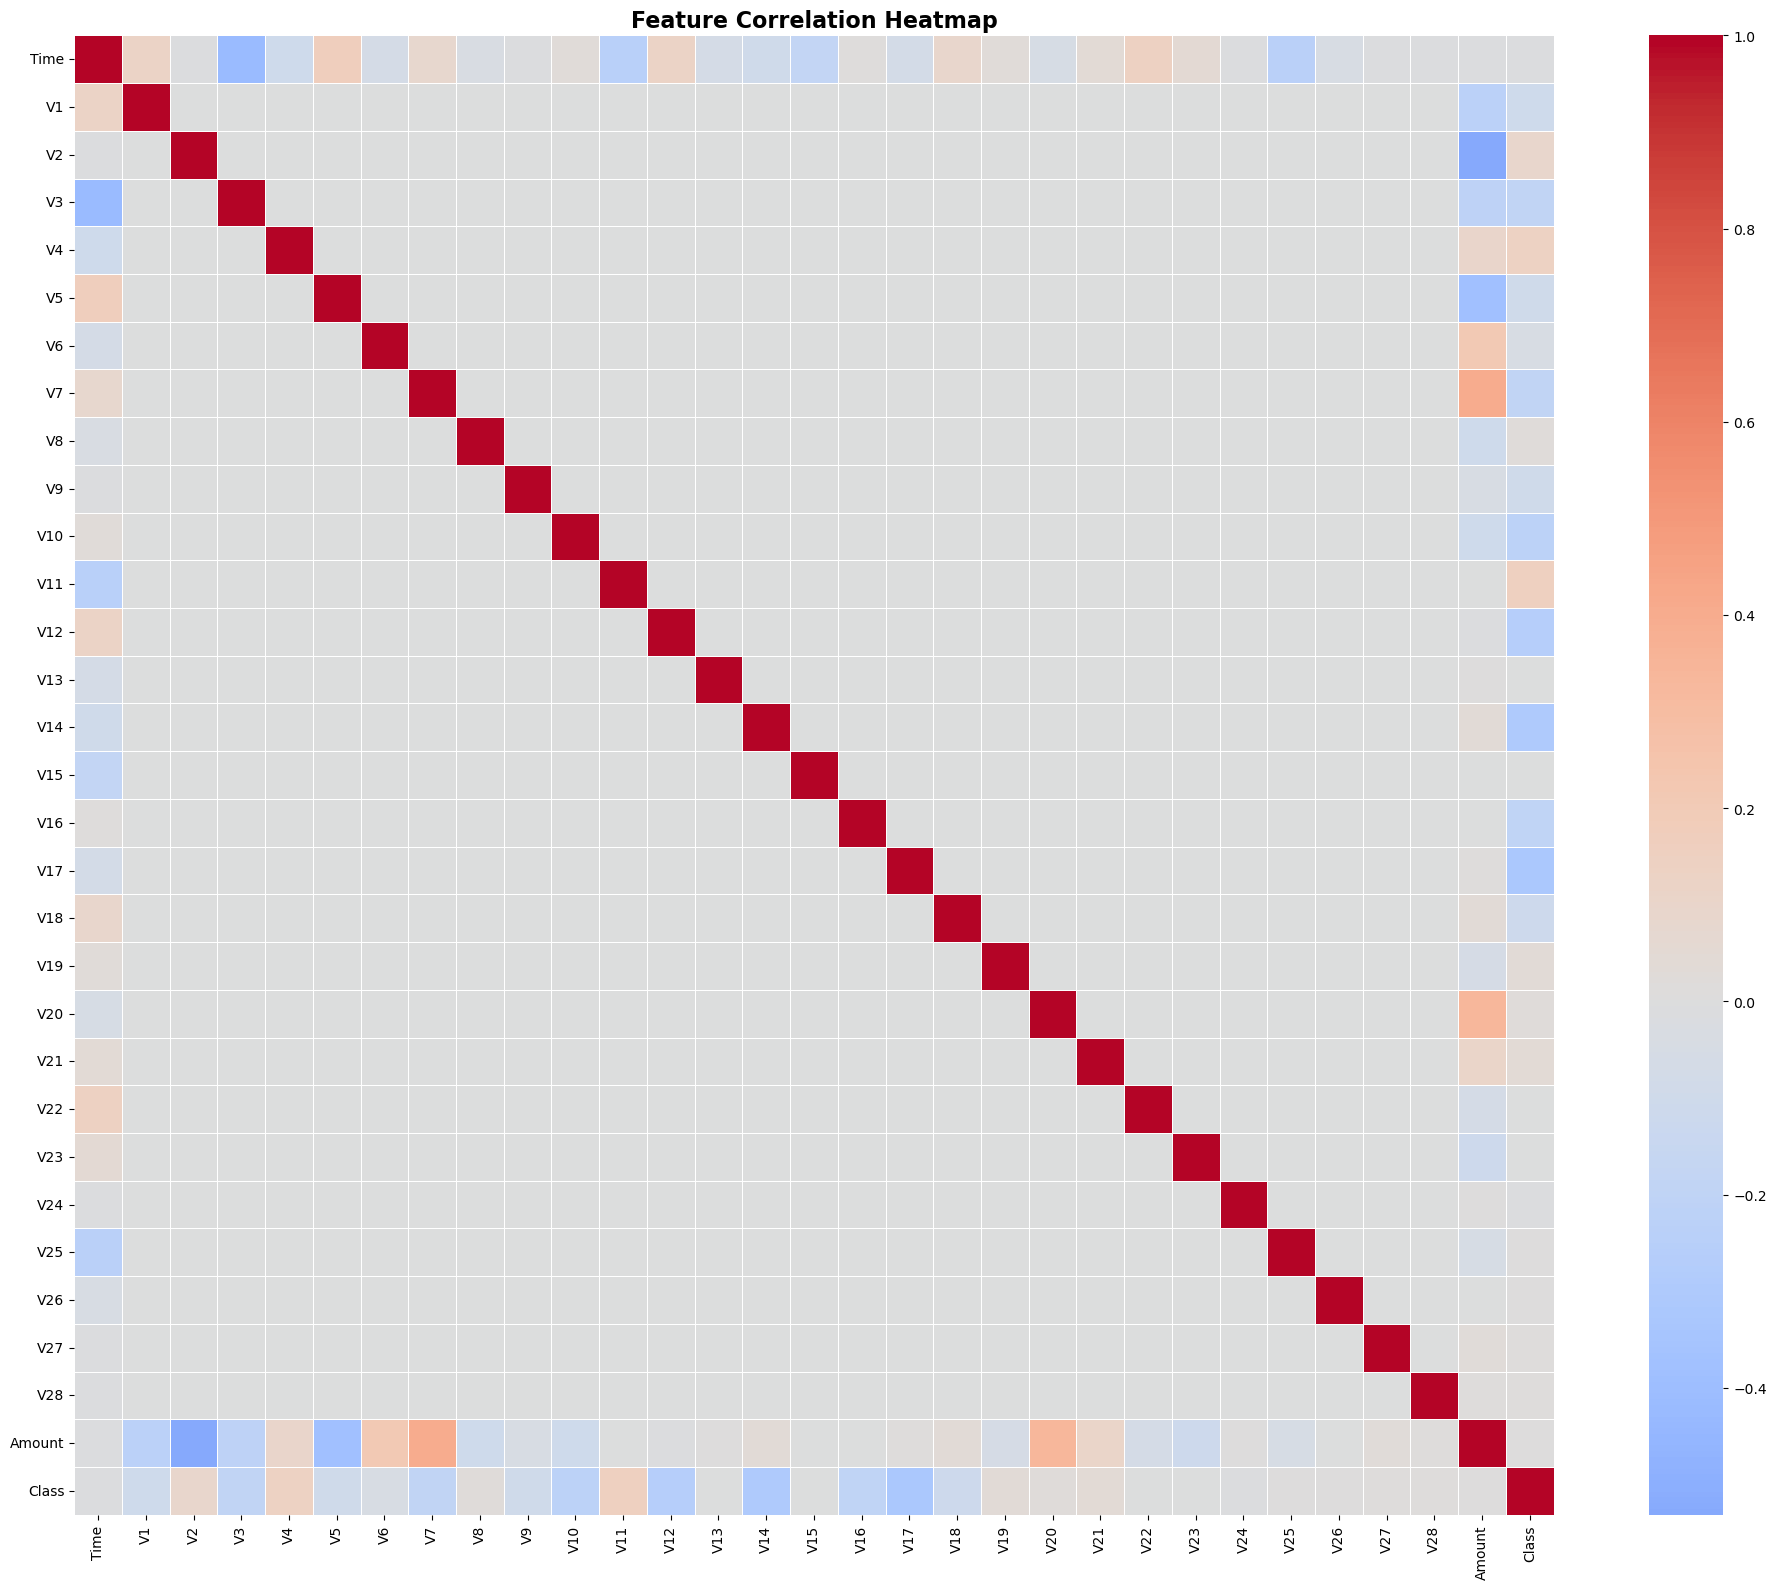

TOP FEATURES CORRELATED WITH FRAUD:
Class    1.000000
V17      0.326481
V14      0.302544
V12      0.260593
V10      0.216883
V16      0.196539
V3       0.192961
V7       0.187257
V11      0.154876
V4       0.133447
Name: Class, dtype: float64


In [19]:
# Correlation heatmap
plt.figure(figsize=(20, 16))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    annot=False,  # True would show numbers (too crowded here)
    fmt='.2f'
)

plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Most correlated features with fraud
print("TOP FEATURES CORRELATED WITH FRAUD:")
fraud_corr = correlation_matrix['Class'].abs().sort_values(ascending=False)
print(fraud_corr.head(10))